# Análisis Global de Mercado: Obra Nueva vs Segunda Mano

Esta notebook consolida los datos de todos los scrapeos locales en `output/`, aplica los filtros estándar, y realiza análisis estadísticos y visuales sobre el precio por metro cuadrado (Price/SqM) para responder a las tres grandes preguntas analíticas.

In [2]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración visual
sns.set_theme(style="whitegrid")

# 1. Consolidación de Datos
output_dir = '../output'
all_data = []
print_lines = []

for folder in os.listdir(output_dir):
    folder_path = os.path.join(output_dir, folder)
    if not os.path.isdir(folder_path):
        continue
    
    # Parsear nombre de la carpeta (Ej: 110000-320000_buy_new_Alic_afueras)
    parts = folder.split('_')
    if len(parts) >= 5 and parts[1].lower() == 'buy':
        p_type = 'New' if 'new' in parts[2].lower() else 'Used'
        city = parts[3].capitalize()
        if city == 'Alic': city = 'Ali'  # Normalizar nombre
        zone = parts[4].capitalize()
        
        # Encontrar CSV
        csvs = glob.glob(os.path.join(folder_path, '*.csv'))
        if not csvs: continue
            
        df = pd.read_csv(csvs[0])
        # Normalizar zona a 'Dentro' o 'Afueras'
        norm_zone = 'Dentro' if 'dentro' in zone.lower() else 'Afueras'
        
        initial_len = len(df)
        
        # Filtros Estrictos (Nulos, Precio > 320k, Area < 65)
        df = df.dropna()
        if 'Price (€)' in df.columns: df = df[df['Price (€)'] <= 320000]
        if 'Area (m²)' in df.columns: df = df[df['Area (m²)'] >= 65]
        
        final_len = len(df)
        type_key = 0 if p_type == 'Used' else 1
        print_lines.append((type_key, city, norm_zone, f"[{p_type:4} | {city:3} | {norm_zone:7}] Originales: {initial_len:4} | Filtradas: {final_len:4}"))
        
        if 'Price (€)' in df.columns and 'Area (m²)' in df.columns and len(df) > 0:
            df['Price/SqM'] = df['Price (€)'] / df['Area (m²)']
            df['Type'] = p_type
            df['City'] = city
            # Normalizar zona a 'Dentro' o 'Afueras'

            df['Zone'] = norm_zone
            df['Location_Full'] = f"{city} {norm_zone}"
            
            all_data.append(df[['Price/SqM', 'Type', 'City', 'Zone', 'Location_Full']])


# Imprimir reporte de filas ordenado
print_lines.sort(key=lambda x: (x[0], x[1], x[2]))
for line in print_lines:
    print(line[3])

df_master = pd.concat(all_data, ignore_index=True)
df_master['Price/SqM'] = df_master['Price/SqM'].astype(float)
print(f"Base de datos consolidada con {len(df_master)} propiedades limpias.")

[Used | Ali | Afueras] Originales:  157 | Filtradas:  157
[Used | Ali | Dentro ] Originales:  171 | Filtradas:  171
[Used | Bcn | Afueras] Originales:  143 | Filtradas:  143
[Used | Bcn | Dentro ] Originales:  131 | Filtradas:  131
[Used | Mal | Afueras] Originales:  124 | Filtradas:  124
[Used | Mal | Dentro ] Originales:  147 | Filtradas:  147
[Used | Sev | Afueras] Originales:  163 | Filtradas:  163
[Used | Sev | Dentro ] Originales:  150 | Filtradas:  150
[Used | Val | Afueras] Originales:  139 | Filtradas:  139
[Used | Val | Dentro ] Originales:  150 | Filtradas:  150
[New  | Ali | Afueras] Originales:  134 | Filtradas:   90
[New  | Ali | Dentro ] Originales:   63 | Filtradas:   36
[New  | Bcn | Afueras] Originales:  139 | Filtradas:   37
[New  | Bcn | Dentro ] Originales:  129 | Filtradas:   19
[New  | Mal | Afueras] Originales:  123 | Filtradas:   35
[New  | Mal | Dentro ] Originales:  135 | Filtradas:   29
[New  | Sev | Afueras] Originales:  371 | Filtradas:  314
[New  | Sev | 

## Pregunta 1: Distribución entre Ciudades por Segmento Específico
Comparamos la dispersión de precios para una misma categoría en distintas ciudades.

C:\Users\mgrinberg\AppData\Local\Temp\ipykernel_27072\3427076961.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='City', y='Price/SqM', order=order, palette='Set2')
C:\Users\mgrinberg\AppData\Local\Temp\ipykernel_27072\3427076961.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='City', y='Price/SqM', order=order, palette='Set2')
C:\Users\mgrinberg\AppData\Local\Temp\ipykernel_27072\3427076961.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='City', y='Price/SqM', order=order, palette=

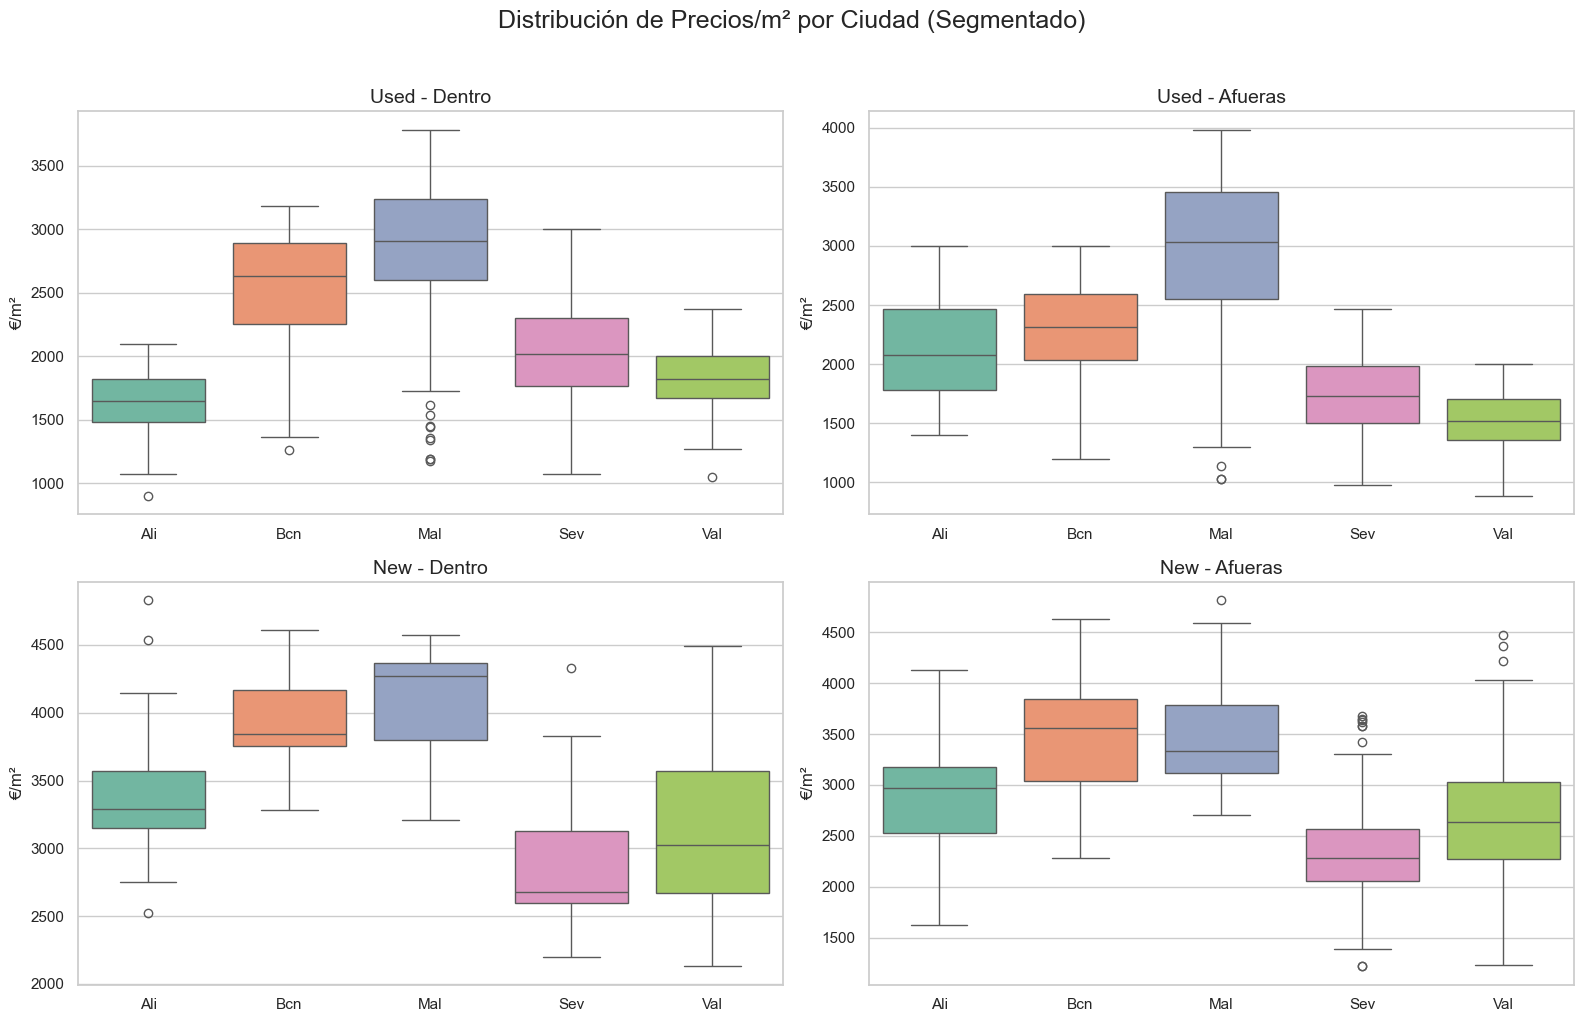

In [2]:
plt.figure(figsize=(16, 10))
plt.suptitle('Distribución de Precios/m² por Ciudad (Segmentado)', fontsize=18, y=1.02)

combinations = [('Used', 'Dentro'), ('Used', 'Afueras'), ('New', 'Dentro'), ('New', 'Afueras')]
order = ['Ali', 'Bcn', 'Mal', 'Sev', 'Val']

for i, (t, z) in enumerate(combinations, 1):
    plt.subplot(2, 2, i)
    subset = df_master[(df_master['Type'] == t) & (df_master['Zone'] == z)]
    
    sns.boxplot(data=subset, x='City', y='Price/SqM', order=order, palette='Set2')
    plt.title(f'{t} - {z}', fontsize=14)
    plt.xlabel('')
    plt.ylabel('€/m²')

plt.tight_layout()
plt.savefig('graph1.png', bbox_inches='tight')
plt.show()

## Pregunta 2: Dinámica Interna de Cada Ciudad
Analizamos cómo varían las medianas de precio entre Used vs New y Dentro vs Afueras para una ciudad en concreto.

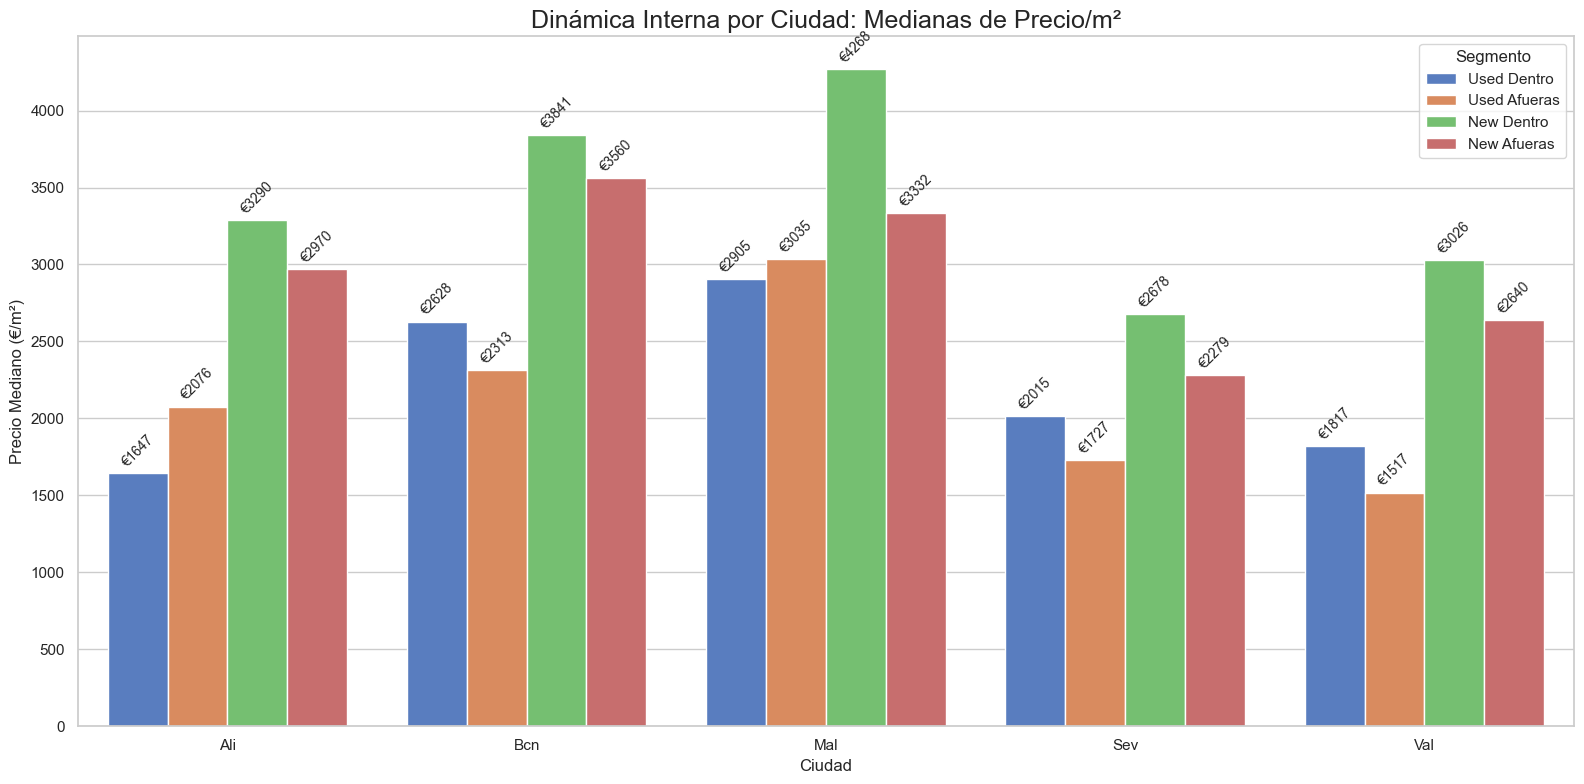


  VARIACIONES PORCENTUALES PROMEDIO (Entre las 5 Ciudades)
🔹 DE AFUERAS AL CENTRO:
   - En pisos Usados aumenta un: +5%
   - En pisos Nuevos aumenta un: +16%
   ► PROMEDIO GENERAL Centro vs Afueras: +10%

🔹 DE USADO A OBRA NUEVA:
   - En las Afueras aumenta un: +43%
   - En el Centro aumenta un: +58%
   ► PROMEDIO GENERAL Nuevo vs Usado: +50%


In [3]:
medians = df_master.groupby(['City', 'Type', 'Zone'])['Price/SqM'].median().reset_index()
medians['Category'] = medians['Type'] + " " + medians['Zone']
category_order = ['Used Dentro', 'Used Afueras', 'New Dentro', 'New Afueras']

plt.figure(figsize=(16, 8))
ax = sns.barplot(data=medians, x='City', y='Price/SqM', hue='Category', 
                 hue_order=category_order, order=order, palette='muted')

plt.title('Dinámica Interna por Ciudad: Medianas de Precio/m²', fontsize=18)
plt.ylabel('Precio Mediano (€/m²)')
plt.xlabel('Ciudad')

# Añadir valores encima de las barras
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.text(p.get_x() + p.get_width()/2., height + 20, f'€{int(height)}', 
                ha="center", va="bottom", fontsize=10, rotation=45)

plt.legend(title='Segmento')
plt.tight_layout()
plt.savefig('graph2.png', bbox_inches='tight')
plt.show()

# --- CÁLCULO DE VARIACIONES PORCENTUALES ---
pivot = medians.pivot_table(index='City', columns=['Type', 'Zone'], values='Price/SqM')

# Variación de Afueras a Centro
used_out_in = ((pivot['Used']['Dentro'] - pivot['Used']['Afueras']) / pivot['Used']['Afueras'] * 100).mean()
new_out_in = ((pivot['New']['Dentro'] - pivot['New']['Afueras']) / pivot['New']['Afueras'] * 100).mean()
avg_out_in = (used_out_in + new_out_in) / 2

# Variación de Usado a Nuevo
in_used_new = ((pivot['New']['Dentro'] - pivot['Used']['Dentro']) / pivot['Used']['Dentro'] * 100).mean()
out_used_new = ((pivot['New']['Afueras'] - pivot['Used']['Afueras']) / pivot['Used']['Afueras'] * 100).mean()
avg_used_new = (in_used_new + out_used_new) / 2

print("\n=======================================================")
print("  VARIACIONES PORCENTUALES PROMEDIO (Entre las 5 Ciudades)")
print("=======================================================")
print(f"🔹 DE AFUERAS AL CENTRO:")
print(f"   - En pisos Usados aumenta un: +{used_out_in:.0f}%")
print(f"   - En pisos Nuevos aumenta un: +{new_out_in:.0f}%")
print(f"   ► PROMEDIO GENERAL Centro vs Afueras: +{avg_out_in:.0f}%")
print("")
print(f"🔹 DE USADO A OBRA NUEVA:")
print(f"   - En las Afueras aumenta un: +{out_used_new:.0f}%")
print(f"   - En el Centro aumenta un: +{in_used_new:.0f}%")
print(f"   ► PROMEDIO GENERAL Nuevo vs Usado: +{avg_used_new:.0f}%")


## Pregunta 3: Visión General del Mercado (Macro)
Estadísticas descriptivas a nivel global (toda España) para New vs Used, y Dentro vs Afueras.

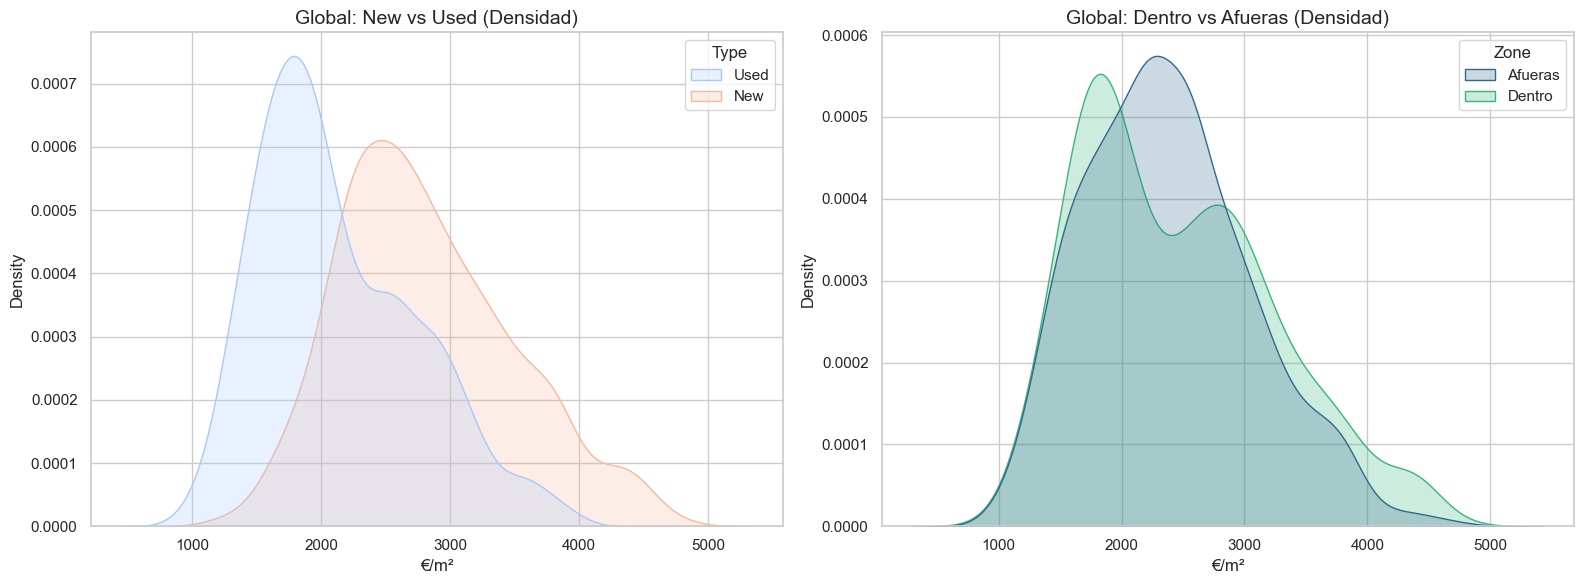

    ESTADÍSTICAS MACRO: NEW vs USED (Global) 


,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
New,1052.0,2815.0,680.0,1217.0,2294.0,2707.0,3258.0,4831.0
Used,1475.0,2122.0,616.0,885.0,1649.0,1981.0,2562.0,3984.0



 ESTADÍSTICAS MACRO: DENTRO vs AFUERAS (Global) 


,count,mean,std,min,25%,50%,75%,max
Zone,,,,,,,,
Afueras,1503.0,2380.0,680.0,885.0,1876.0,2317.0,2811.0,4815.0
Dentro,1024.0,2455.0,793.0,899.0,1810.0,2344.0,2987.0,4831.0


In [6]:
plt.figure(figsize=(16, 6))

# KDE New vs Used
plt.subplot(1, 2, 1)
sns.kdeplot(data=df_master, x='Price/SqM', hue='Type', fill=True, common_norm=False, palette='coolwarm')
plt.title('Global: New vs Used (Densidad)', fontsize=14)
plt.xlabel('€/m²')

# KDE Dentro vs Afueras
plt.subplot(1, 2, 2)
sns.kdeplot(data=df_master, x='Price/SqM', hue='Zone', fill=True, common_norm=False, palette='viridis')
plt.title('Global: Dentro vs Afueras (Densidad)', fontsize=14)
plt.xlabel('€/m²')

plt.tight_layout()
plt.savefig('graph3.png', bbox_inches='tight')
plt.show()

print("==============================================")
print("    ESTADÍSTICAS MACRO: NEW vs USED (Global) ")
print("==============================================")
display(df_master.groupby('Type')['Price/SqM'].describe().round(0))

print("\n==============================================")
print(" ESTADÍSTICAS MACRO: DENTRO vs AFUERAS (Global) ")
print("==============================================")
display(df_master.groupby('Zone')['Price/SqM'].describe().round(0))

## Pregunta 4: Densidad de los 4 Grupos
Comparación general superponiendo los 4 grupos.

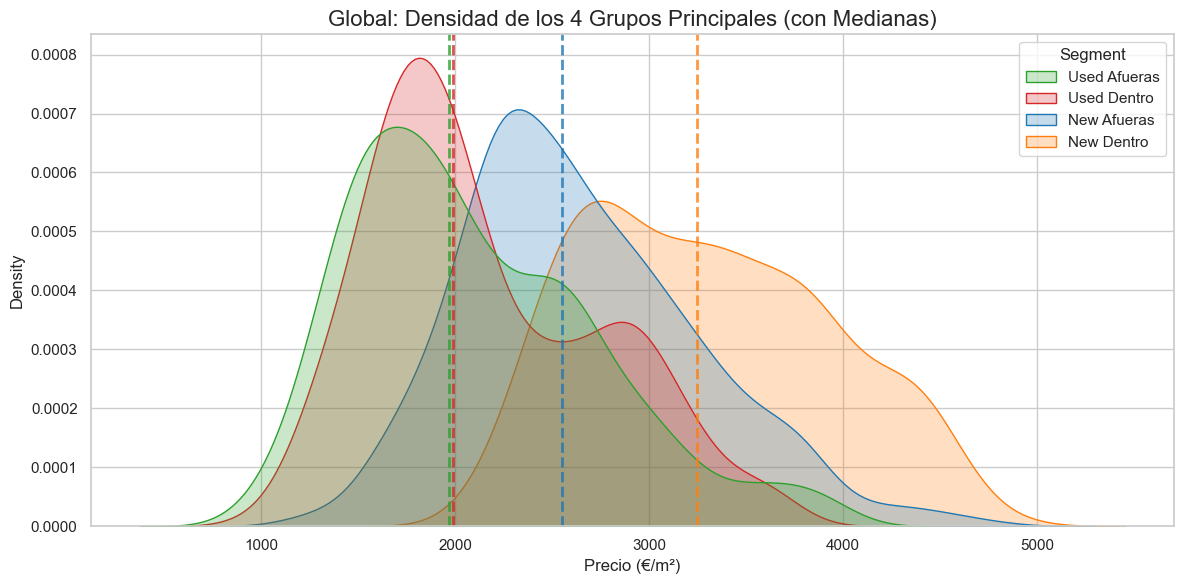

In [7]:
plt.figure(figsize=(12, 6))
df_master['Segment'] = df_master['Type'] + " " + df_master['Zone']

# Asignar colores fijos a cada segmento para que coincidan las curvas y las líneas
segments = sorted(df_master['Segment'].dropna().unique())
palette = sns.color_palette('tab10', len(segments))
color_dict = dict(zip(segments, palette))

ax = sns.kdeplot(data=df_master, x='Price/SqM', hue='Segment', fill=True, common_norm=False, palette=color_dict)

# Añadir líneas verticales para las medianas
for seg in segments:
    median_val = df_master[df_master['Segment'] == seg]['Price/SqM'].median()
    ax.axvline(median_val, color=color_dict[seg], linestyle='--', linewidth=2, alpha=0.8)
    # Opcional: Escribir el texto de la mediana junto a la línea
    # ax.text(median_val + 10, ax.get_ylim()[1]*0.9, f'€{int(median_val)}', color=color_dict[seg], rotation=90)

plt.title('Global: Densidad de los 4 Grupos Principales (con Medianas)', fontsize=16)
plt.xlabel('Precio (€/m²)')
plt.tight_layout()
plt.savefig('graph4.png', bbox_inches='tight')
plt.show()


## Generador de Reporte HTML Independiente
Guarda todos los gráficos generados en un único archivo HTML listo para compartir.

In [8]:
import base64
import webbrowser

def get_base64_image(image_path):
    with open(image_path, "rb") as image_file:
        encoded_string = base64.b64encode(image_file.read()).decode('utf-8')
    return f"data:image/png;base64,{encoded_string}"

css_styles = """
    <style>
        body { font-family: Arial, sans-serif; background-color: #f4f4f9; color: #333; padding: 20px; }
        h1 { text-align: center; color: #2c3e50; }
        .container { display: flex; flex-direction: column; gap: 40px; margin-top: 30px; }
        .card { background: white; padding: 15px; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); text-align: center; }
        .card img { max-width: 100%; height: auto; border-radius: 4px; }
    </style>
"""

html = f"<!DOCTYPE html><html lang='es'><head><meta charset='UTF-8'><title>Reporte Global</title>{css_styles}</head><body>"
html += "<h1>Análisis Global del Mercado Inmobiliario</h1><div class='container'>"

sections = ["1. Distribución por Ciudad", "2. Dinámica Interna", "3. Macro (New vs Used / Dentro vs Afueras)", "4. Macro (4 Grupos)"]
for i, title in enumerate(sections, 1):
    img_path = f"graph{i}.png"
    if os.path.exists(img_path):
        html += f"<div class='card'><h2>{title}</h2><img src='{get_base64_image(img_path)}' alt='Graph {i}'></div>"

html += "</div></body></html>"
report_filename = "reporte_global_independiente.html"
with open(report_filename, "w", encoding="utf-8") as f:
    f.write(html)


# Limpieza de archivos temporales
import os
for i in range(1, 5):
    img_path = f"graph{i}.png"
    if os.path.exists(img_path):
        os.remove(img_path)
print(f"¡Reporte HTML guardado en {report_filename}!")
webbrowser.open('file://' + os.path.realpath(report_filename))


¡Reporte HTML guardado en reporte_global_independiente.html!


True